# Practice 09 — Multilayer Perceptron (MLP)

**다층 퍼셉트론**을 구현합니다.

| # | 내용 | 구현 |
|---|---|---|
| 1 | XOR 문제 — 단층 vs 다층 | PyTorch |
| 2 | PyTorch MLP로 XOR 해결 | `nn.Module` class |
| 3 | Multi-class Criterion 변화 | `nn.Module` class |
| 4 | `nn.Sequential` — 또 다른 정의 방법 | `nn.Sequential` |

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn import datasets

---
# 1. XOR 문제 — 왜 다층이 필요한가?

XOR은 **선형 분리 불가능**한 문제입니다. 단층 퍼셉트론으로는 해결할 수 없고, 은닉층이 필요합니다.

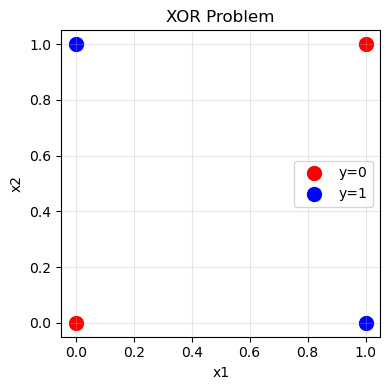

In [2]:
# XOR 데이터
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float64)
Y_xor = np.array([[0], [1], [1], [0]], dtype=np.float64)

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.scatter(X_xor[Y_xor.flatten()==0, 0], X_xor[Y_xor.flatten()==0, 1], c='r', s=100, label='y=0')
ax.scatter(X_xor[Y_xor.flatten()==1, 0], X_xor[Y_xor.flatten()==1, 1], c='b', s=100, label='y=1')
ax.set_title('XOR Problem'); ax.legend(); ax.grid(alpha=0.3)
ax.set_xlabel('x1'); ax.set_ylabel('x2')
plt.tight_layout(); plt.show()

### 단층 퍼셉트론 — 실패

In [3]:
# 단층 퍼셉트론으로 XOR 시도
X_t = torch.tensor(X_xor, dtype=torch.float32)
y_t = torch.tensor(Y_xor, dtype=torch.float32)

torch.manual_seed(42)
model_single = nn.Linear(2, 1)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_single.parameters(), lr=0.5)

for epoch in range(1000):
    loss = criterion(model_single(X_t), y_t)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

with torch.no_grad():
    pred = (torch.sigmoid(model_single(X_t)) >= 0.5).int().flatten()
    acc = (pred == y_t.int().flatten()).float().mean()

print(f'Single layer prediction: {pred.numpy()}')
print(f'True labels:             {Y_xor.flatten().astype(int)}')
print(f'Accuracy: {acc:.0%}  <- XOR is linearly inseparable!')

Single layer prediction: [1 1 1 1]
True labels:             [0 1 1 0]
Accuracy: 50%  <- XOR is linearly inseparable!


---
# 2. PyTorch MLP로 XOR 해결 — `nn.Module` class

은닉층 하나만 추가하면 XOR을 풀 수 있습니다.

**구조:** Input(2) → Linear(4) → Sigmoid → Linear(1)

PyTorch에서 모델을 정의할 때 가장 표준적인 방식은 `nn.Module`을 상속받는 **클래스**로 만드는 것입니다.

- `__init__`: 사용할 레이어들을 멤버 변수로 저장
- `forward`: 입력이 들어와 출력이 나오는 흐름을 정의 (gradient는 PyTorch가 자동 계산)

In [4]:
# nn.Module 을 상속받아 MLP 정의
class XOR_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 4)              # 은닉층
        self.fc2 = nn.Linear(4, 1)              # 출력층

    def forward(self, x):
        x = torch.sigmoid(self.fc1(x))          # 은닉층 + sigmoid
        return self.fc2(x)                       # logit 반환 (BCEWithLogitsLoss가 sigmoid 내장)

torch.manual_seed(42)
model = XOR_MLP()
print(model)

XOR_MLP(
  (fc1): Linear(in_features=2, out_features=4, bias=True)
  (fc2): Linear(in_features=4, out_features=1, bias=True)
)


In [5]:
# 학습
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1.0)

X_t = torch.tensor(X_xor, dtype=torch.float32)
y_t = torch.tensor(Y_xor, dtype=torch.float32)

loss_hist = []
for epoch in range(5000):
    loss = criterion(model(X_t), y_t)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    loss_hist.append(loss.item())

# 학습 결과 확인
with torch.no_grad():
    pred = torch.sigmoid(model(X_t))
    print('=== XOR MLP Result ===')
    for i in range(4):
        print(f'  x={X_xor[i]}  ->  o={pred[i].item():.4f}  (target={Y_xor[i,0]:.0f})')

=== XOR MLP Result ===
  x=[0. 0.]  ->  o=0.0010  (target=0)
  x=[0. 1.]  ->  o=0.9983  (target=1)
  x=[1. 0.]  ->  o=0.9990  (target=1)
  x=[1. 1.]  ->  o=0.0015  (target=0)


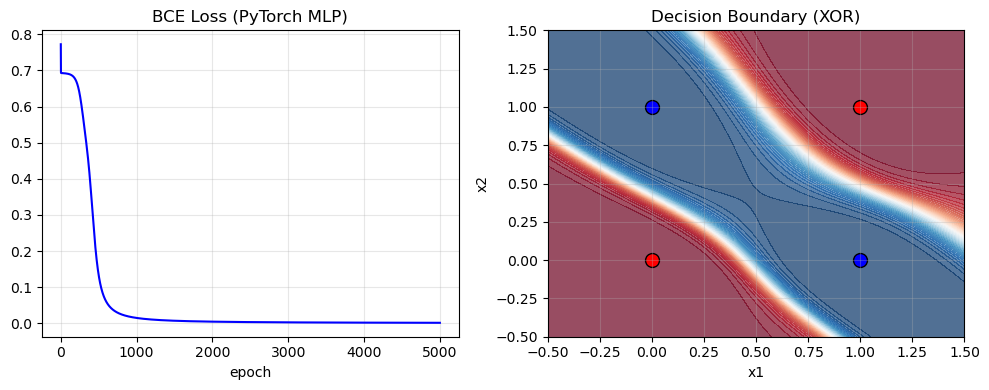

In [6]:
# 학습 곡선 + 결정 경계 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# (a) Loss curve
axes[0].plot(loss_hist, 'b-', lw=1.5)
axes[0].set_title('BCE Loss (PyTorch MLP)'); axes[0].set_xlabel('epoch'); axes[0].grid(alpha=0.3)

# (b) Decision boundary
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_t = torch.tensor(grid, dtype=torch.float32)
with torch.no_grad():
    prob = torch.sigmoid(model(grid_t)).numpy().reshape(xx.shape)

axes[1].contourf(xx, yy, prob, levels=50, cmap='RdBu', alpha=0.7)
axes[1].scatter(X_xor[Y_xor.flatten()==0, 0], X_xor[Y_xor.flatten()==0, 1], c='r', s=100, edgecolors='k')
axes[1].scatter(X_xor[Y_xor.flatten()==1, 0], X_xor[Y_xor.flatten()==1, 1], c='b', s=100, edgecolors='k')
axes[1].set_title('Decision Boundary (XOR)'); axes[1].set_xlabel('x1'); axes[1].set_ylabel('x2')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
# 3. Multi-class 출력 시 Criterion 변화

XOR은 출력이 1개(binary)였습니다.
실제 문제에서는 **여러 클래스를 분류**해야 하는 경우가 대부분입니다. (예: 숫자 0~9, 동물 종류 등)

출력이 **binary**에서 **multi-class**로 바뀔 때, activation과 loss가 다음과 같이 변합니다.

| | Binary (XOR) | Multi-class |
|---|---|---|
| **출력 노드** | 1 | C (클래스 수) |
| **Activation** | sigmoid | softmax (또는 생략) |
| **Loss** | `BCEWithLogitsLoss` | `CrossEntropyLoss` |
| **Label 형태** | `float (0/1)` | `long (클래스 인덱스)` |
| **예측** | `sigmoid(z) >= 0.5` | `argmax(logits)` |

### 3.1 Binary — `nn.Module` class

In [7]:
# Binary MLP: 2 -> 4 -> 1 (sigmoid + BCEWithLogitsLoss)
class BinaryMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 4)
        self.fc2 = nn.Linear(4, 1)

    def forward(self, x):
        x = torch.sigmoid(self.fc1(x))
        return self.fc2(x)                       # logit 반환

torch.manual_seed(0)
model_bin = BinaryMLP()
crit_bin = nn.BCEWithLogitsLoss()
opt_bin = torch.optim.SGD(model_bin.parameters(), lr=1.0)

X_t = torch.tensor(X_xor, dtype=torch.float32)
y_bin = torch.tensor(Y_xor, dtype=torch.float32)   # (N, 1), float

for ep in range(3000):
    loss = crit_bin(model_bin(X_t), y_bin)
    loss.backward(); opt_bin.step(); opt_bin.zero_grad()

with torch.no_grad():
    prob = torch.sigmoid(model_bin(X_t))            # sigmoid로 확률 변환
    pred = (prob >= 0.5).int().flatten()
print('=== Binary (XOR) ===')
print(f'  Prediction: {pred.numpy()}')
print(f'  Labels:     {Y_xor.flatten().astype(int)}')
print(f'  Loss: {loss.item():.4f}')

=== Binary (XOR) ===
  Prediction: [0 1 1 0]
  Labels:     [0 1 1 0]
  Loss: 0.0030


### 3.2 Multi-class — `nn.Module` class

In [8]:
# Multi-class MLP: 4 -> 16 -> 3 (ReLU + CrossEntropyLoss)
class MultiMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 16)
        self.fc2 = nn.Linear(16, 3)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)                       # logits (CrossEntropyLoss가 softmax 내장)

iris = datasets.load_iris()
X_iris = torch.tensor(iris.data, dtype=torch.float32)
y_iris = torch.tensor(iris.target, dtype=torch.long)  # (N,), long 정수 인덱스

torch.manual_seed(0)
model_mc = MultiMLP()
crit_mc = nn.CrossEntropyLoss()                       # softmax + NLL 내장
opt_mc = torch.optim.Adam(model_mc.parameters(), lr=0.01)

for ep in range(300):
    logits = model_mc(X_iris)                          # (N, 3) — softmax 적용 전
    loss = crit_mc(logits, y_iris)
    loss.backward(); opt_mc.step(); opt_mc.zero_grad()

with torch.no_grad():
    pred = model_mc(X_iris).argmax(dim=1)              # argmax로 예측 클래스 선택
    acc = (pred == y_iris).float().mean()
print('=== Multi-class (Iris 3-class) ===')
print(f'  Accuracy: {acc:.1%}')
print(f'  Loss: {loss.item():.4f}')
print(f'')
print(f'  y_iris dtype: {y_iris.dtype}  (long 정수 — 클래스 인덱스)')
print(f'  y_bin  dtype: {y_bin.dtype}   (float — 0.0/1.0)')

=== Multi-class (Iris 3-class) ===
  Accuracy: 98.0%
  Loss: 0.0527

  y_iris dtype: torch.int64  (long 정수 — 클래스 인덱스)
  y_bin  dtype: torch.float32   (float — 0.0/1.0)


---
# 4. `nn.Sequential` — 또 다른 정의 방법

지금까지 모델은 모두 `nn.Module`을 상속한 **클래스**로 정의했습니다.

레이어가 단순히 **순차적으로 쌓이는 구조**라면, 클래스를 만들지 않고 `nn.Sequential`로 한 줄에 정의할 수도 있습니다.

| | `nn.Module` class | `nn.Sequential` |
|---|---|---|
| **정의** | `__init__` + `forward` 메서드 작성 | 레이어를 순서대로 나열 |
| **장점** | 분기·반복 등 복잡한 흐름 표현 가능, 디버깅 쉬움 | 짧고 직관적 |
| **단점** | 코드가 약간 길어짐 | 단순한 sequential 구조만 가능 |
| **언제 쓰나** | 기본 권장 (확장성) | 단순한 MLP, 빠른 prototyping |

> 본 수업에서는 `nn.Module` class 방식을 기본으로 사용합니다. 다만 다른 자료에서 `nn.Sequential`이 자주 보이므로, 같은 모델이라는 점만 기억하면 됩니다.

In [9]:
# 같은 MLP를 두 방식으로 정의

# (a) nn.Module class
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 16)
        self.fc2 = nn.Linear(16, 3)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

torch.manual_seed(0)
model_cls = SimpleMLP()

# (b) nn.Sequential
torch.manual_seed(0)
model_seq = nn.Sequential(
    nn.Linear(4, 16),
    nn.ReLU(),
    nn.Linear(16, 3),
)

print('--- (a) nn.Module class ---')
print(model_cls)
print('')
print('--- (b) nn.Sequential ---')
print(model_seq)

--- (a) nn.Module class ---
SimpleMLP(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=3, bias=True)
)

--- (b) nn.Sequential ---
Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=3, bias=True)
)


In [10]:
# 같은 데이터로 두 모델을 같은 방식으로 학습 -> 결과 동일
def train(model, X, y, n_iter=300, lr=0.01):
    crit = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(n_iter):
        loss = crit(model(X), y)
        loss.backward(); opt.step(); opt.zero_grad()
    with torch.no_grad():
        acc = (model(X).argmax(dim=1) == y).float().mean().item()
    return loss.item(), acc

loss_a, acc_a = train(model_cls, X_iris, y_iris)
loss_b, acc_b = train(model_seq, X_iris, y_iris)

print(f'(a) nn.Module class : loss={loss_a:.4f}, acc={acc_a:.1%}')
print(f'(b) nn.Sequential   : loss={loss_b:.4f}, acc={acc_b:.1%}')
print('')
print('같은 구조 + 같은 seed -> 결과 동일. 두 방식은 표현만 다를 뿐 같은 모델입니다.')

(a) nn.Module class : loss=0.0527, acc=98.0%
(b) nn.Sequential   : loss=0.0527, acc=98.0%

같은 구조 + 같은 seed -> 결과 동일. 두 방식은 표현만 다를 뿐 같은 모델입니다.
